<a href="https://colab.research.google.com/github/dickypp/Recommender-System-Project/blob/main/BoardGame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install surprise

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Board Game Dataset/user_ratings.csv')

# Mengubah nama kolom
df.columns = ['Game_Id', 'Rating','User_Id']

# Random Sampling
np.random.seed(42)
# Unik user
unique_users = df['User_Id'].unique()
# Sampling 10% user
sample_fraction = 0.10
sampled_users = np.random.choice(unique_users, size=int(len(unique_users) * sample_fraction), replace=False)
df_sampled = df[df['User_Id'].isin(sampled_users)]

print(f"Total users: {len(unique_users)}")
print(f"Sampled users: {len(sampled_users)}")
print(f"Sampled interactions: {len(df_sampled)}")

# Hapus nilai kosong
df_sampled = df_sampled.dropna(subset=['Game_Id', 'Rating', 'User_Id'])

# Hapus duplikasi user dan game
df_sampled = df_sampled.drop_duplicates(subset=['User_Id', 'Game_Id'])

# Membulatkan nilai rating
df_sampled['Rating'] = df_sampled['Rating'].round(1)

print(df_sampled.head(10))

Total users: 411375
Sampled users: 41137
Sampled interactions: 1889661
     Game_Id  Rating        User_Id
24    213788     7.0        lemados
81    193500     5.0      kelvbrown
83    193500     5.0  thatthing1999
85    193500     5.0   RyanThibault
87    193500     5.0       aralias1
117   193500     4.0         CDrust
123   193500     3.0        Benji68
128   193500     3.0        MrMoo28
130   193500     3.0         CindyV
140   193500     3.0       mhillebr


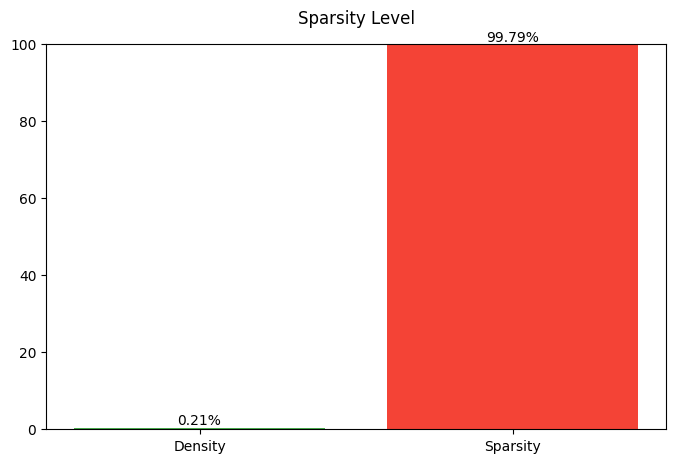

In [ ]:
# Hitung sparsity
num_users = df_sampled['User_Id'].nunique()
num_games = df_sampled['Game_Id'].nunique()
num_ratings = len(df_sampled)

sparsity = 1 - num_ratings / (num_users * num_games)

density = 1 - sparsity
values = [density * 100, sparsity * 100]

# Visualisasi
plt.figure(figsize=(8, 5))
plt.bar(['Density', 'Sparsity'], values, color=['#4CAF50', '#F44336'])
plt.title('Sparsity Level', fontsize=12, pad=15)
plt.ylim(0, 100)

# Tambah label persentase di atas bar
for i, val in enumerate(values):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center', fontsize=10)

plt.savefig('sparsity_level.png', dpi=300, bbox_inches='tight')
plt.show()

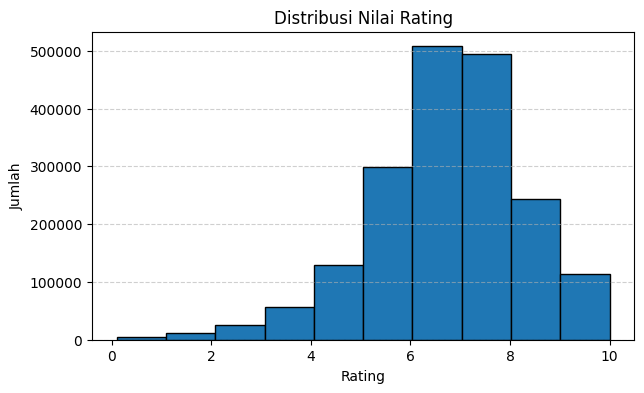

In [ ]:
# Distribusi nilai rating
plt.figure(figsize=(7,4))
plt.hist(df_sampled["Rating"], bins=10, edgecolor="black")
plt.title("Distribusi Nilai Rating", fontsize=12)
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('distribusi nilai.png', dpi=300, bbox_inches='tight')
plt.show()

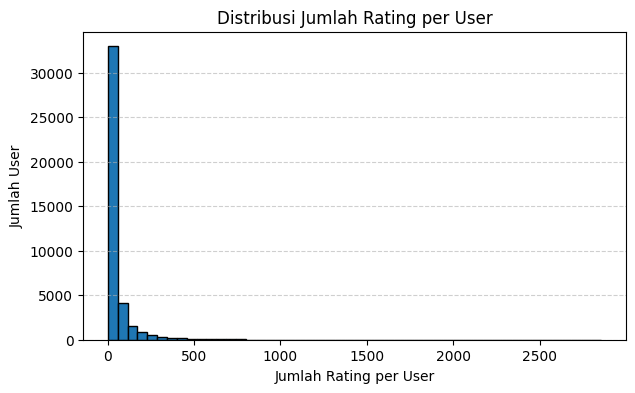

In [ ]:
# Jumlah rating per user
plt.figure(figsize=(7,4))
df_sampled["User_Id"].value_counts().plot(kind='hist', bins=50, edgecolor='black')
plt.title("Distribusi Jumlah Rating per User", fontsize=12)
plt.xlabel("Jumlah Rating per User")
plt.ylabel("Jumlah User")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('jumlah rating.png', dpi=300, bbox_inches='tight')
plt.show()

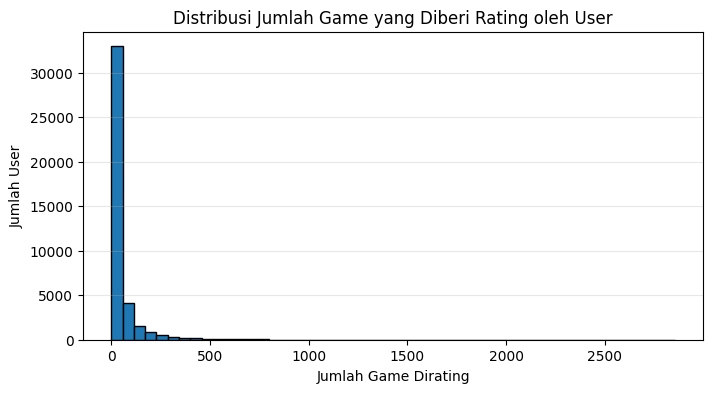

In [ ]:
# Jumlah
ratings_per_user = df_sampled.groupby('User_Id').size().reset_index(name='Total')

# Grafik
plt.figure(figsize=(8,4))
plt.hist(ratings_per_user['Total'], bins=50, edgecolor='black')
plt.title('Distribusi Jumlah Game yang Diberi Rating oleh User')
plt.xlabel('Jumlah Game Dirating')
plt.ylabel('Jumlah User')
plt.grid(axis='y', alpha=0.3)
plt.savefig('jumlah game.png', dpi=300, bbox_inches='tight')
plt.show()

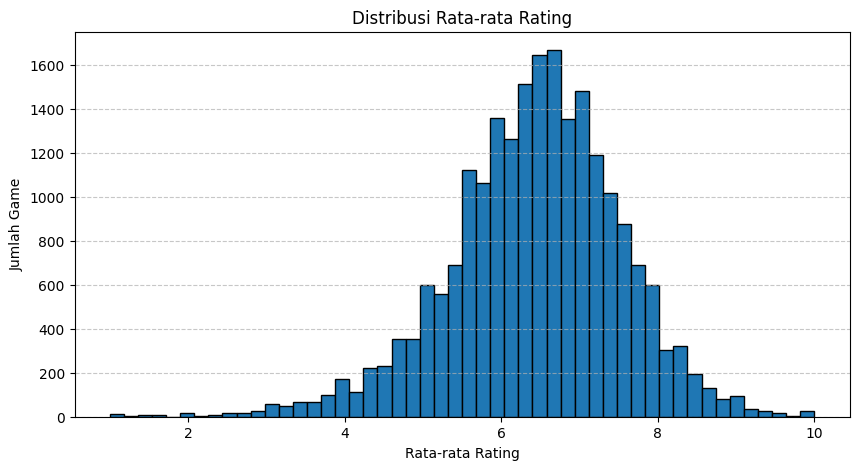

In [ ]:
# Menghitung rata-rata rating
mean_ratings = df_sampled.groupby('Game_Id')['Rating'].mean()

plt.figure(figsize=(10,5))
plt.hist(mean_ratings, bins=50, edgecolor='black')
plt.title('Distribusi Rata-rata Rating')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Jumlah Game')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('rata-rata rating.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Grafik Statistik User
top_users = ratings_per_user.sort_values(by='Total', ascending=False).head(50)

fig = px.bar(
    top_users,
    x='User_Id',
    y='Total',
    title='User Rating',
    text='Total',
    color='Total',
    color_continuous_scale='Blues'
)

fig.update_traces(
    hovertemplate='<b>User ID:</b> %{x}<br><b>Jumlah Rating:</b> %{y}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='User ID',
    yaxis_title='Jumlah Game di Rating',
    xaxis_tickangle=-45,
    title_x=0.5
)

fig.show()

In [ ]:
from surprise import Dataset, Reader, accuracy, SVDpp
from surprise.model_selection import cross_validate, KFold
import itertools


# Model Surprise
reader = Reader(rating_scale=(0, 10))
data = Dataset.load_from_df(df_sampled[['User_Id', 'Game_Id', 'Rating']], reader)

# Parameter
parameters = {
    'n_factors': [75, 100],
    'n_epochs': [20],
    'lr_all': [0.001],
    'reg_all': [0.01, 0.03, 0.05]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for nf in parameters['n_factors']:
    for ne in parameters['n_epochs']:
        for lr in parameters['lr_all']:
            for reg in parameters['reg_all']:
                params = {
                    'n_factors': nf,
                    'n_epochs': ne,
                    'lr_all': lr,
                    'reg_all': reg
                }

                fold = 1
                for trainset, testset in kf.split(data):
                    model = SVDpp(**params)
                    model.fit(trainset)
                    prediction = model.test(testset)
                    rmse = accuracy.rmse(prediction, verbose=False)
                    mae = accuracy.mae(prediction, verbose=False)
                    print(params, "Fold:", fold, "RMSE:", rmse, "MAE:", mae)
                    fold += 1

{'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.003, 'reg_all': 0.01} Fold: 1 RMSE: 1.1915549454025811 MAE: 0.891300019257495
{'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.003, 'reg_all': 0.01} Fold: 2 RMSE: 1.1946616743398242 MAE: 0.8932234943222638
{'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.003, 'reg_all': 0.01} Fold: 3 RMSE: 1.1967102174701227 MAE: 0.894544251998031
{'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.003, 'reg_all': 0.01} Fold: 4 RMSE: 1.1965192215787535 MAE: 0.8948484972663437
{'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.003, 'reg_all': 0.01} Fold: 5 RMSE: 1.1930248097716634 MAE: 0.8925845574718602
